Name: **Robb Ryan P. Calvez**  
Year & Section: **BS CpE 3A**


**Fashion Classification Assessment**

---

### **Import Libraries**

In [1]:
import tensorflow as tf
import pandas as pd
import numpy as np
import sklearn
import matplotlib as mpl
import matplotlib.pyplot as plt
import itertools

from tensorflow.keras.datasets import fashion_mnist
from sklearn.metrics import confusion_matrix


print(f'Tensorflow: {tf.__version__}\n',
      f'Pandas: {pd.__version__}\n',
      f'numpy: {np.__version__}\n',
      f'sklearn: {sklearn.__version__}\n')


2026-06-16 16:06:46.655799: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-16 16:06:46.697771: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-16 16:06:46.715489: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-16 16:06:46.777585: I tensorflow/core/platform/cpu_feature_guard.cc:211] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX, in other operations, rebuild TensorFlow with the appropriate compiler flags.


Tensorflow: 2.17.0
 Pandas: 2.2.3
 numpy: 1.26.4
 sklearn: 1.5.2



### **Prep Dataset**

In [2]:
(train_data, train_labels), (test_data, test_labels) = fashion_mnist.load_data()

In [3]:
train_data.shape, train_labels.shape

((60000, 28, 28), (60000,))

In [4]:
train_data[1]

array([[  0,   0,   0,   0,   0,   1,   0,   0,   0,   0,  41, 188, 103,
         54,  48,  43,  87, 168, 133,  16,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   1,   0,   0,   0,  49, 136, 219, 216, 228, 236,
        255, 255, 255, 255, 217, 215, 254, 231, 160,  45,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  14, 176, 222, 224, 212, 203, 198, 196,
        200, 215, 204, 202, 201, 201, 201, 209, 218, 224, 164,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0, 188, 219, 200, 198, 202, 198, 199, 199,
        201, 196, 198, 198, 200, 200, 200, 200, 201, 200, 225,  41,   0,
          0,   0],
       [  0,   0,   0,   0,  51, 219, 199, 203, 203, 212, 238, 248, 250,
        245, 249, 246, 247, 252, 248, 235, 207, 203, 203, 222, 140,   0,
          0,   0],
       [  0,   0,   0,   0, 116, 226, 206, 204, 207, 204, 101,  75,  47,
         73,  48,  50,  45,  51,  63, 113, 222, 202, 206, 220, 224,   0,
          0,   0],
       [  

In [5]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

len(class_names)

10

In [6]:
train_data_normalized = train_data / 255.0
test_data_normalized = test_data / 255.0

train_data_normalized.min(), train_data_normalized.max()

(0.0, 1.0)

### **Find the Ideal Learning Rate**

#### **Ideal Learning Rate for Raw Data**

In [7]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/30))

history = model.fit(train_data, train_labels, 
                    epochs=150,
                    callbacks=[lr_callback])  



I0000 00:00:1781626014.367070     136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781626015.322568     136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781626015.322700     136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781626015.330477     136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1781626015.330574     136 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:04:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Epoch 1/150


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
I0000 00:00:1781626018.113071     203 service.cc:146] XLA service 0x7b0f01c66f10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781626018.113484     203 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 5060, Compute Capability 12.0
2026-06-16 16:06:58.130696: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-16 16:06:58.483141: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 92000
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature

  19/1875 [..............................] - ETA: 11s - loss: 117.5520 - accuracy: 0.1036   

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 13s 6ms/step - loss: 16.4894 - accuracy: 0.4080 - lr: 1.0000e-05
Epoch 2/150
1875/1875 [==============================] - 12s 7ms/step - loss: 3.0145 - accuracy: 0.4328 - lr: 1.0798e-05
Epoch 3/150
1875/1875 [==============================] - 11s 6ms/step - loss: 2.0668 - accuracy: 0.5070 - lr: 1.1659e-05
Epoch 4/150
1875/1875 [==============================] - 11s 6ms/step - loss: 1.6799 - accuracy: 0.5534 - lr: 1.2589e-05
Epoch 5/150
1875/1875 [==============================] - 12s 7ms/step - loss: 1.4542 - accuracy: 0.5804 - lr: 1.3594e-05
Epoch 6/150
1875/1875 [==============================] - 10s 5ms/step - loss: 1.2941 - accuracy: 0.6002 - lr: 1.4678e-05
Epoch 7/150
1875/1875 [==============================] - 10s 5ms/step - loss: 1.1211 - accuracy: 0.6420 - lr: 1.5849e-05
Epoch 8/150
1875/1875 [==============================] - 13s 7ms/step - loss: 0.9741 - accuracy: 0.6936 - lr: 1.7113e-05
Epoch 9/150
1875/1875 [====================

KeyboardInterrupt: 

In [ ]:
lrs = 1e-5 * (10 ** (np.arange(150)/30))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 5e-4``` is the safest option.

#### **Ideal Learning Rate for Normalized Data**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
              metrics=['accuracy'])

lr_callback = tf.keras.callbacks.LearningRateScheduler(lambda epoch: 1e-5 * 10**(epoch/30))

history = model.fit(train_data_normalized, train_labels, 
                    epochs=150,
                    callbacks=[lr_callback])  



Epoch 1/100


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


   5/1875 [..............................] - ETA: 24s - loss: 2.3236 - accuracy: 0.1375  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 12s 6ms/step - loss: 1.5497 - accuracy: 0.5320 - lr: 1.0000e-05
Epoch 2/100
1875/1875 [==============================] - 13s 7ms/step - loss: 0.9035 - accuracy: 0.7186 - lr: 1.1220e-05
Epoch 3/100
1875/1875 [==============================] - 10s 5ms/step - loss: 0.7115 - accuracy: 0.7783 - lr: 1.2589e-05
Epoch 4/100
1875/1875 [==============================] - 10s 5ms/step - loss: 0.6237 - accuracy: 0.8021 - lr: 1.4125e-05
Epoch 5/100
1875/1875 [==============================] - 13s 7ms/step - loss: 0.5704 - accuracy: 0.8156 - lr: 1.5849e-05
Epoch 6/100
1875/1875 [==============================] - 10s 5ms/step - loss: 0.5323 - accuracy: 0.8253 - lr: 1.7783e-05
Epoch 7/100
1875/1875 [==============================] - 10s 5ms/step - loss: 0.5038 - accuracy: 0.8330 - lr: 1.9953e-05
Epoch 8/100
1875/1875 [==============================] - 13s 7ms/step - loss: 0.4802 - accuracy: 0.8402 - lr: 2.2387e-05
Epoch 9/100
1875/1875 [=====================

In [ ]:
lrs = 1e-5 * (10 ** (np.arange(150)/30))
plt.figure(figsize=(10, 7))
plt.semilogx(lrs, history.history["loss"]) 
plt.xlabel("Learning Rate") 
plt.ylabel("Loss")
plt.title("Learning rate vs. loss");

as per the graph above, somewhere around ```learning_rate = 4e-5``` is the safest option.

### **Create Model with Optimal Learning Rate**

#### **Model Trained on Raw Data**

In [ ]:
tf.random.set_seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])  
model.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=4e-5),
              metrics=['accuracy'])

history = model.fit(train_data, train_labels, 
                    epochs=20,
                    validation_data=(test_data, test_labels)
                    )

Epoch 1/20
   1/1875 [..............................] - ETA: 2:05:13 - loss: 119.0003 - accuracy: 0.1250

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 16s 7ms/step - loss: 13.1212 - accuracy: 0.6793 - val_loss: 7.3723 - val_accuracy: 0.7459
Epoch 2/20
1875/1875 [==============================] - 14s 8ms/step - loss: 5.8991 - accuracy: 0.7688 - val_loss: 5.3188 - val_accuracy: 0.7743
Epoch 3/20
1875/1875 [==============================] - 11s 6ms/step - loss: 4.3349 - accuracy: 0.7882 - val_loss: 4.3928 - val_accuracy: 0.7666
Epoch 4/20
1875/1875 [==============================] - 11s 6ms/step - loss: 3.3563 - accuracy: 0.7983 - val_loss: 3.3568 - val_accuracy: 0.7844
Epoch 5/20
1875/1875 [==============================] - 14s 7ms/step - loss: 2.5828 - accuracy: 0.8003 - val_loss: 2.6237 - val_accuracy: 0.7790
Epoch 6/20
1875/1875 [==============================] - 11s 6ms/step - loss: 1.8353 - accuracy: 0.7921 - val_loss: 1.7411 - val_accuracy: 0.7594
Epoch 7/20
1875/1875 [==============================] - 13s 7ms/step - loss: 1.1547 - accuracy: 0.7784 - val_loss: 1.2909 - val_accuracy: 0.

#### **Model Trained on Normalized Data**

In [ ]:
model_normalized = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(10, activation='softmax')
])  

model_normalized.compile(loss='sparse_categorical_crossentropy',
              optimizer=tf.keras.optimizers.Adam(learning_rate=4e-5),
              metrics=['accuracy'])

history = model_normalized.fit(train_data_normalized, train_labels, 
                    epochs=20,
                    validation_data=(test_data_normalized, test_labels)
                    )

Epoch 1/20


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  24/1875 [..............................] - ETA: 12s - loss: 2.2104 - accuracy: 0.1979

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


1875/1875 [==============================] - 15s 7ms/step - loss: 0.9141 - accuracy: 0.7248 - val_loss: 0.6495 - val_accuracy: 0.7864
Epoch 2/20
1875/1875 [==============================] - 12s 6ms/step - loss: 0.5747 - accuracy: 0.8123 - val_loss: 0.5586 - val_accuracy: 0.8139
Epoch 3/20
1875/1875 [==============================] - 14s 7ms/step - loss: 0.5081 - accuracy: 0.8315 - val_loss: 0.5162 - val_accuracy: 0.8242
Epoch 4/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.4730 - accuracy: 0.8420 - val_loss: 0.4873 - val_accuracy: 0.8338
Epoch 5/20
1875/1875 [==============================] - 10s 5ms/step - loss: 0.4502 - accuracy: 0.8499 - val_loss: 0.4716 - val_accuracy: 0.8387
Epoch 6/20
1875/1875 [==============================] - 13s 7ms/step - loss: 0.4330 - accuracy: 0.8546 - val_loss: 0.4604 - val_accuracy: 0.8420
Epoch 7/20
1875/1875 [==============================] - 9s 5ms/step - loss: 0.4201 - accuracy: 0.8575 - val_loss: 0.4486 - val_accuracy: 0.84

### **Display Results**

In [ ]:
import random

# Create a function for plotting a random image along with its prediction
def plot_random_image(model, images, true_labels, classes):
  """Picks a random image, plots it and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    images: a set of random images (in tensor form).
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.

  Returns:
    A plot of a random image from `images` with a predicted class label from `model`
    as well as the truth class label from `true_labels`.
  """
  # Setup random integer
  i = random.randint(0, len(images))

  # Create predictions and targets
  target_image = images[i]
  pred_probs = model.predict(target_image.reshape(1, 28, 28)) # have to reshape to get into right size for model
  pred_label = classes[pred_probs.argmax()]
  true_label = classes[true_labels[i]]

  # Plot the target image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add xlabel information (prediction/true label)
  plt.xlabel("Pred: {} {:2.0f}% (True: {})".format(pred_label,
                                                   100*tf.reduce_max(pred_probs),
                                                   true_label),
             color=color) # set the color to green or red

In [ ]:

def plot_image(model, images, true_labels, classes, index):
  """Plots a single image and labels it with a predicted and truth label.

  Args:
    model: a trained model (trained on data similar to what's in images).
    target: the index of the image to plot.
    true_labels: array of ground truth labels for images.
    classes: array of class names for images.

  Returns:
    A plot of the image at index `target`.
  """
  
  # Select image and true label
  target_image = images[index]
  true_label = classes[true_labels[index]]

  # Predict on one image
  pred_probs = model.predict(tf.expand_dims(target_image, axis=0)) 
  pred_label = classes[pred_probs.argmax()]

  # Plot the target image
  plt.imshow(target_image, cmap=plt.cm.binary)

  # Change the color of the titles depending on if the prediction is right or wrong
  if pred_label == true_label:
    color = "green"
  else:
    color = "red"

  # Add xlabel information (prediction/true label)
  plt.xlabel(
        f"Pred: {pred_label} {100 * tf.reduce_max(pred_probs):.2f}% | True: {true_label}",
        color=color
    ) # set the color to green or red

In [ ]:
def make_confusion_matrix(y_true, y_pred, classes=None, figsize=(10, 10), text_size=15):
  """Makes a labelled confusion matrix comparing predictions and ground truth labels.

  If classes is passed, confusion matrix will be labelled, if not, integer class values
  will be used.

  Args:
    y_true: Array of truth labels (must be same shape as y_pred).
    y_pred: Array of predicted labels (must be same shape as y_true).
    classes: Array of class labels (e.g. string form). If `None`, integer labels are used.
    figsize: Size of output figure (default=(10, 10)).
    text_size: Size of output figure text (default=15).

  Returns:
    A labelled confusion matrix plot comparing y_true and y_pred.

  Example usage:
    make_confusion_matrix(y_true=test_labels, # ground truth test labels
                          y_pred=y_preds, # predicted labels
                          classes=class_names, # array of class label names
                          figsize=(15, 15),
                          text_size=10)
  """
  # Create the confustion matrix
  cm = confusion_matrix(y_true, y_pred)
  cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] # normalize it
  n_classes = cm.shape[0] # find the number of classes we're dealing with

  # Plot the figure and make it pretty
  fig, ax = plt.subplots(figsize=figsize)
  cax = ax.matshow(cm, cmap=plt.cm.Blues) # colors will represent how 'correct' a class is, darker == better
  fig.colorbar(cax)

  # Are there a list of classes?
  if classes:
    labels = classes
  else:
    labels = np.arange(cm.shape[0])

  # Label the axes
  ax.set(title="Confusion Matrix",
         xlabel="Predicted label",
         ylabel="True label",
         xticks=np.arange(n_classes), # create enough axis slots for each class
         yticks=np.arange(n_classes),
         xticklabels=labels, # axes will labeled with class names (if they exist) or ints
         yticklabels=labels)

  # Make x-axis labels appear on bottom
  ax.xaxis.set_label_position("bottom")
  ax.xaxis.tick_bottom()

  # Set the threshold for different colors
  threshold = (cm.max() + cm.min()) / 2.

  # Plot the text on each cell
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, f"{cm[i, j]} ({cm_norm[i, j]*100:.1f}%)",
             horizontalalignment="center",
             color="white" if cm[i, j] > threshold else "black",
             size=text_size)

#### **Accuracy / Loss Graph**

Text(0, 0.5, 'Loss')

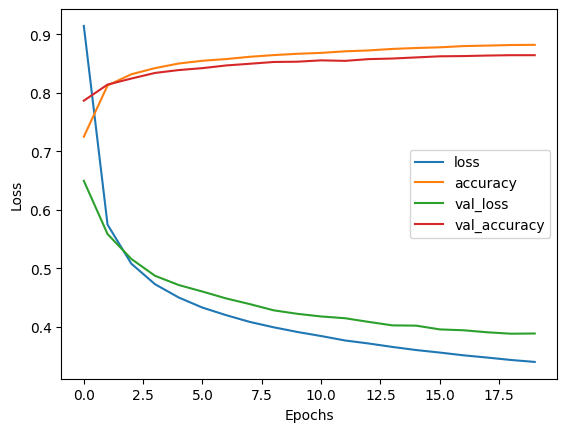

In [ ]:
pd.DataFrame(history.history).plot()
mpl.pyplot.xlabel('Epochs')
mpl.pyplot.ylabel('Loss')

#### **Normalized vs Raw Training Sets**

1/1 [==============================] - 0s 26ms/step


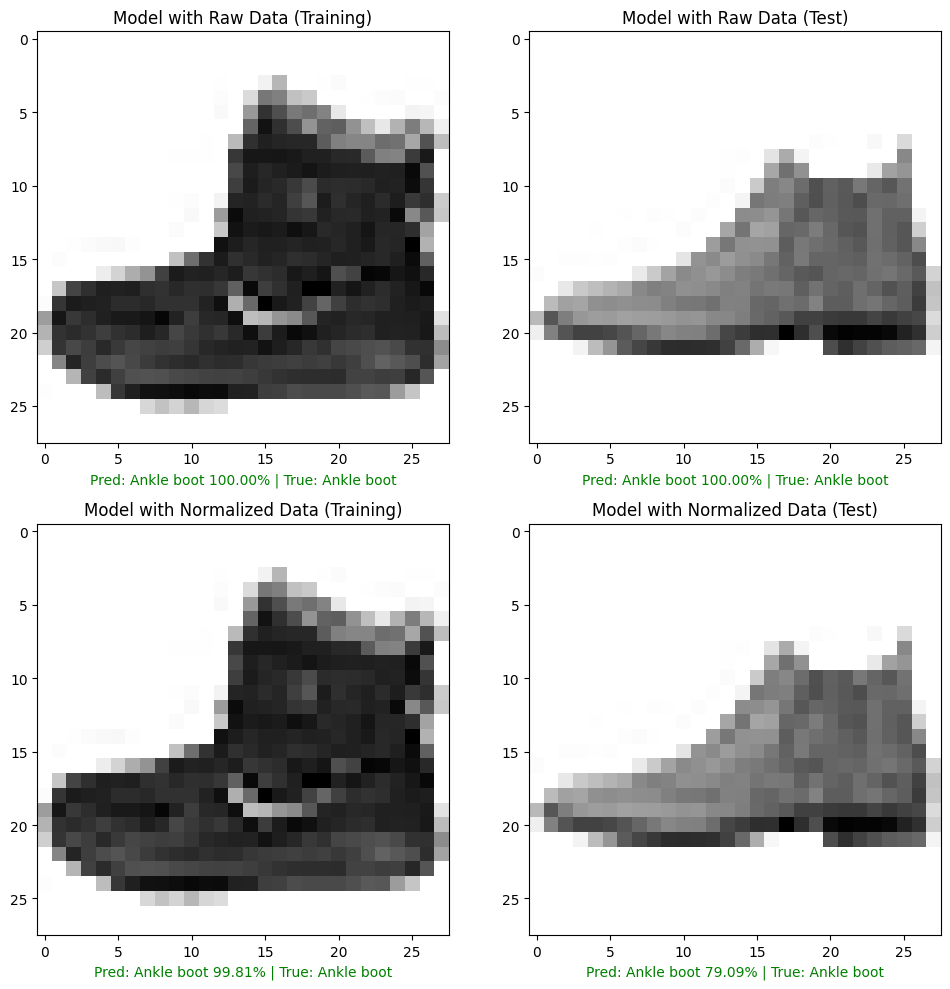

In [ ]:
plt.figure(figsize=(10, 10))

plots = [
    ('Model with Raw Data (Training)', model, train_data, train_labels),
    ('Model with Raw Data (Test)', model, test_data, test_labels),
    ('Model with Normalized Data (Training)', model_normalized, train_data_normalized, train_labels),
    ('Model with Normalized Data (Test)', model_normalized, test_data_normalized, test_labels)
]

for i, (title, selected_model, img_data, labels) in enumerate(plots):
    plt.subplot(2, 2, i + 1)   # create/select subplot first
    plt.title(title)           # then set title on that subplot

    plot_image(
        selected_model,
        img_data,
        labels,
        class_names,
        0
    )

plt.tight_layout()


#### **Confusion Matrix**

In [ ]:
y_probs = model.predict(test_data)
y_probs[0].argmax(), class_names[y_probs[0].argmax()]
y_preds = y_probs.argmax(axis=1)

In [ ]:
confusion_matrix(y_true=test_labels,
                 y_pred=y_preds)

array([[846,   2,  11,  22,  13,   2, 101,   0,   3,   0],
       [  2, 972,   3,  10,   9,   0,   3,   1,   0,   0],
       [ 13,   1, 740,   9, 180,   0,  57,   0,   0,   0],
       [ 19,   6,   7, 888,  53,   0,  23,   0,   4,   0],
       [  0,   0,  58,  16, 902,   0,  24,   0,   0,   0],
       [  0,   0,   0,   0,   0, 965,   0,  25,   2,   8],
       [126,   1,  81,  29, 122,   0, 637,   0,   4,   0],
       [  0,   0,   0,   0,   0,   6,   0, 981,   0,  13],
       [  4,   0,   6,   5,  10,   5,   9,   2, 959,   0],
       [  0,   0,   0,   0,   0,  10,   1,  58,   0, 931]])

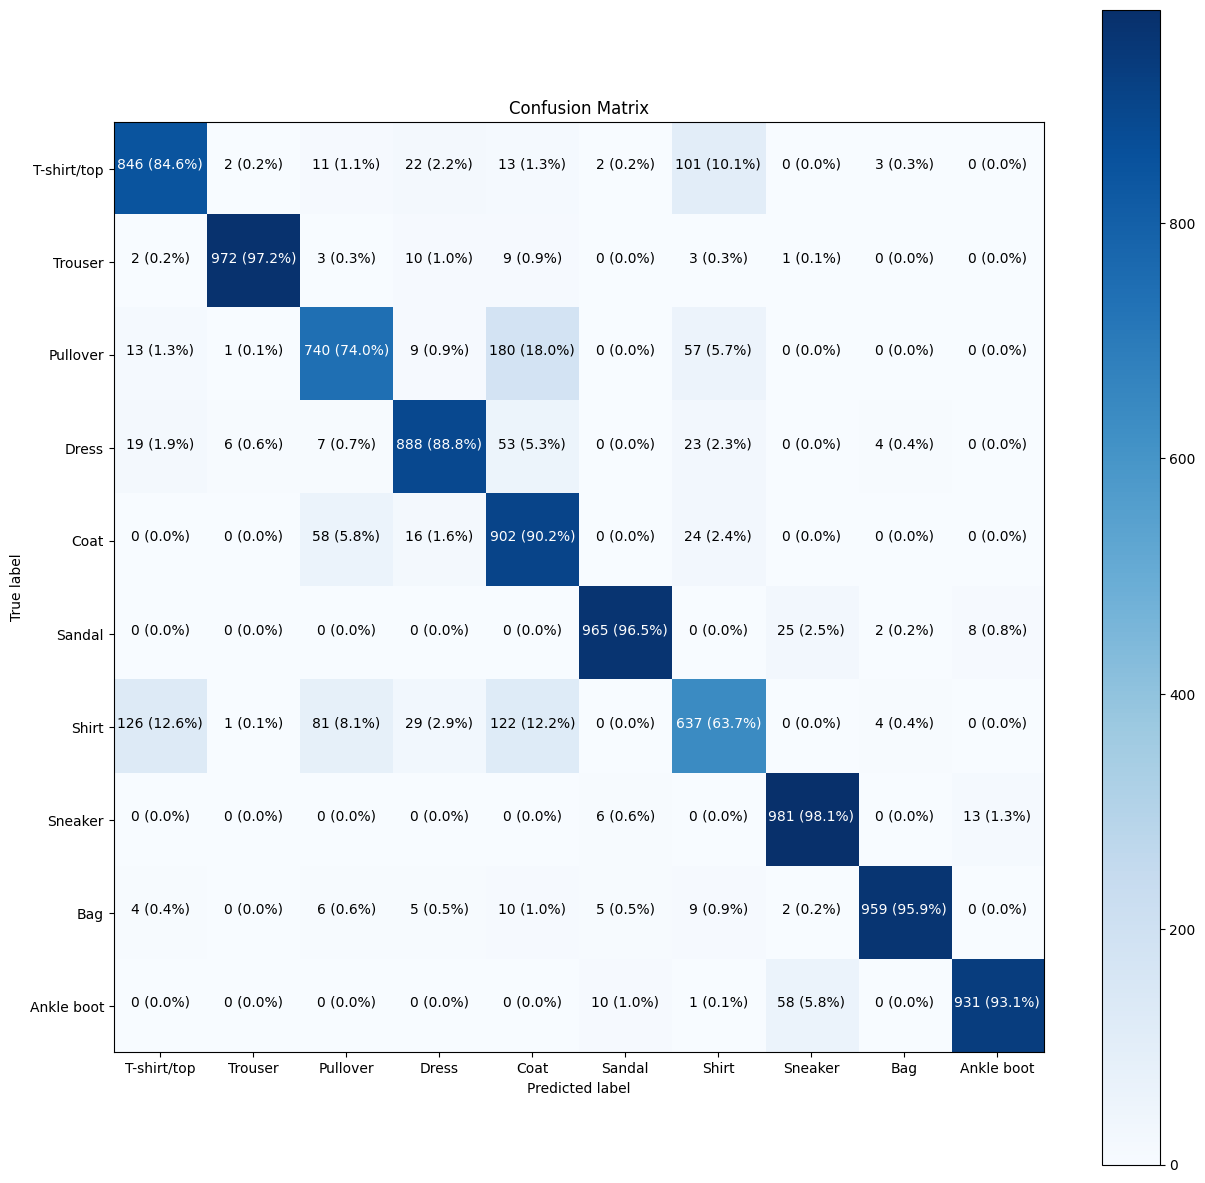

In [ ]:
make_confusion_matrix(y_true=test_labels,
                      y_pred=y_preds,
                      classes=class_names,
                      figsize=(15, 15),
                      text_size=10)

#### **Random Sample Predictions**

1/1 [==============================] - 0s 23ms/step


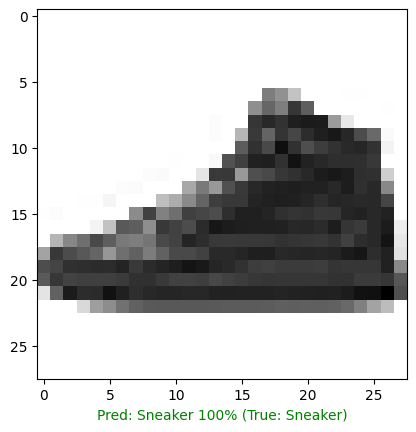

In [ ]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 27ms/step


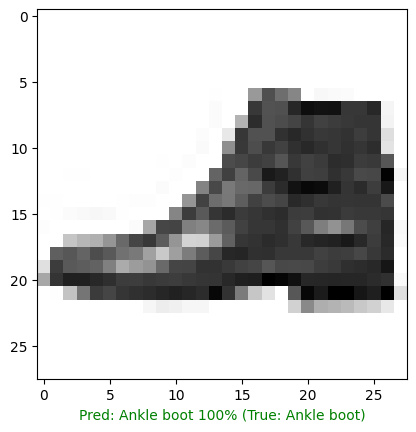

In [ ]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 32ms/step


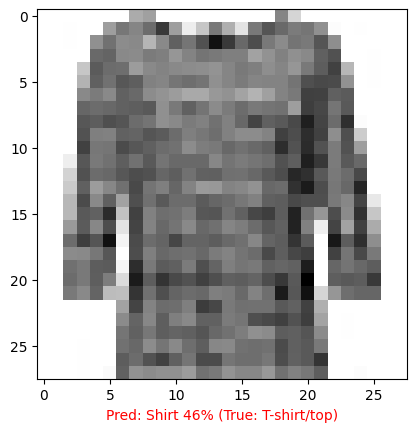

In [ ]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 30ms/step


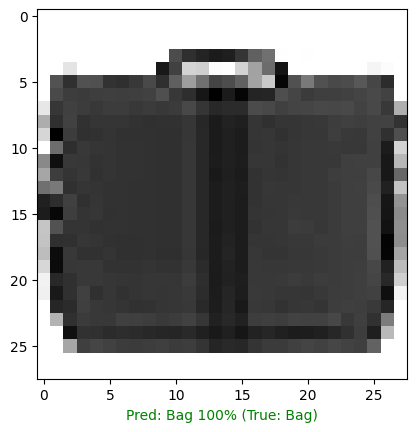

In [ ]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)

1/1 [==============================] - 0s 30ms/step


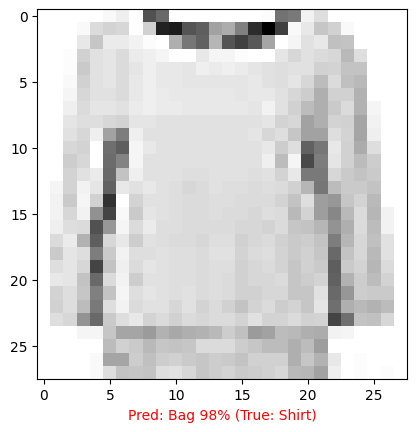

In [ ]:
plot_random_image(model=model,
                  images=test_data,
                  true_labels=test_labels,
                  classes=class_names)